Фильтр Блума

In [38]:
import math
import hashlib
import random
import matplotlib.pyplot as plt

In [39]:
class CountingBloomFilter:
    def __init__(self, n=None, epsilon=None, m=None, k=None):
        if m is None and n is not None and epsilon is not None: 
            self.m = int(- (n * math.log(epsilon)) / (math.log(2) ** 2))
        elif m is not None:
            self.m = m

        if k is None and n is not None:
            self.k = int(round((self.m / n) * math.log(2)))
        elif k is not None:
            self.k = k

        self.counters = [0] * self.m
    
    def hash_pos(self, elem, i):
        variance = f"variant7_bloom_{i}".encode()

        h = hashlib.blake2b(str(elem).encode(), key=variance, digest_size=4)
        hash_val = int.from_bytes(h.digest(), 'big')
        hash_val %= 2 ** 30

        return hash_val % self.m

    def add(self, elem):
        for i in range(self.k):
            pos = self.hash_pos(elem, i)
            self.counters[pos] += 1
    
    def remove(self, elem):
        for i in range(self.k):
            pos = self.hash_pos(elem, i)
            if self.counters[pos] > 0:
                self.counters[pos] -= 1
    
    def check(self, elem):
        return all(self.counters[self.hash_pos(elem, i)] > 0 for i in range(self.k))
    
    def __add__(self, other):
        new_bf = CountingBloomFilter(m=self.m, k=self.k)
        new_bf.counters = [max(a, b) for a, b in zip(self.counters, other.counters)]
        return new_bf
    
    def __sub__(self, other):
        new_bf = CountingBloomFilter(m=self.m, k=self.k)
        new_bf.counters = [min(a, b) for a, b in zip(self.counters, other.counters)]
        return new_bf
    
    def get_theoretical_fpr(self, n_current):
        if self.m == 0 or n_current == 0:
            return 0.0
        return (1 - math.exp(-self.k * n_current / self.m)) ** self.k

=== ЗАПУСК БАЗОВЫХ ТЕСТОВ ===
Тест 1: Пустой фильтр OK
Тест 2: Добавление и проверка OK
Тест 3: Удаление OK
Тест 4: Большое множество OK, точность=100.00%

=== Тест объединения (+) ===
Объединение: все проверки пройдены

=== Тест пересечения (-) ===
Пересечение: все проверки пройдены

=== Конфигурация 1: n=15000, ε=0.5 ===
Рассчитанные параметры: m=21640, k=1
  Наполненность 25%: Эксперимент=0.1704, Теория=0.1591, Отклонение=0.0113
  Наполненность 50%: Эксперимент=0.3026, Теория=0.2929, Отклонение=0.0097
  Наполненность 75%: Эксперимент=0.4092, Теория=0.4054, Отклонение=0.0038
  Наполненность 95%: Эксперимент=0.4865, Теория=0.4824, Отклонение=0.0041

=== Конфигурация 2: n=100000, ε=0.2 ===
Рассчитанные параметры: m=334983, k=2
  Наполненность 25%: Эксперимент=0.0184, Теория=0.0192, Отклонение=0.0008
  Наполненность 50%: Эксперимент=0.0660, Теория=0.0666, Отклонение=0.0006
  Наполненность 75%: Эксперимент=0.1294, Теория=0.1303, Отклонение=0.0009
  Наполненность 95%: Эксперимент=0.1866, 

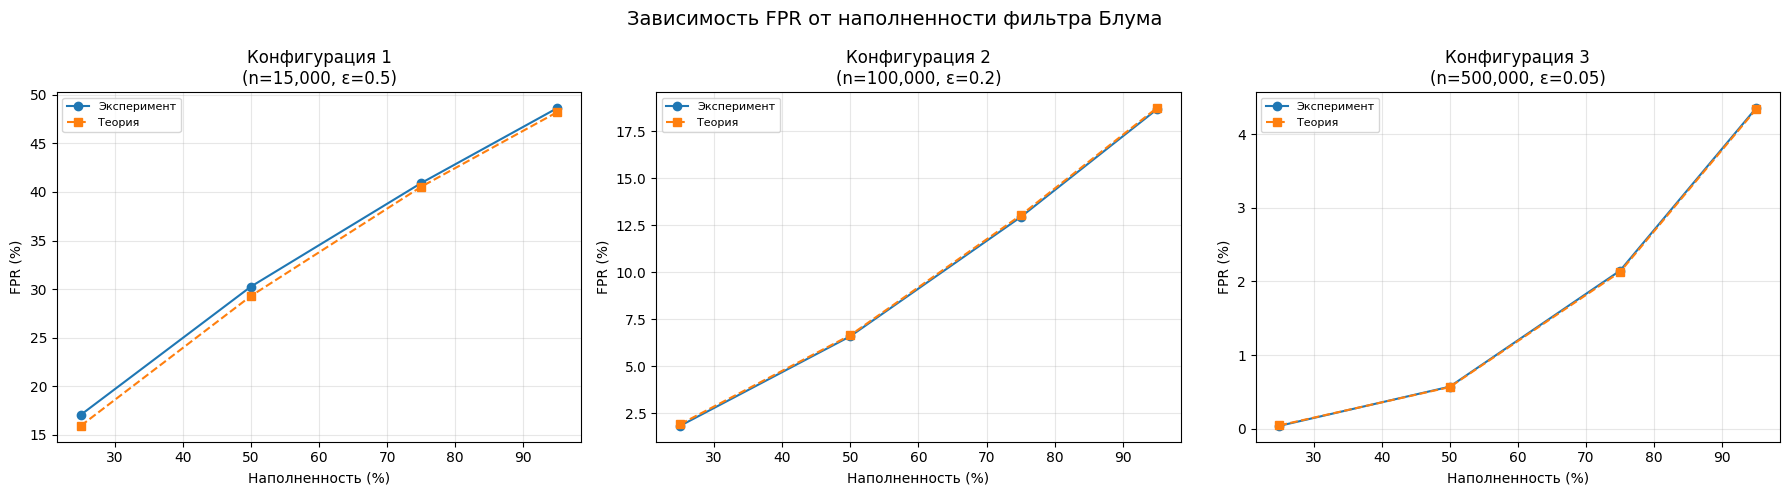

In [ ]:
def theoretical_fpr(m, k, n_current):
    if m == 0 or n_current == 0:
        return 0.0
    return (1 - math.exp(-k * n_current / m)) ** k


def stream_generator(seed=None):
    if seed is not None:
        random.seed(seed)
    while True:
        yield f"data_{random.randint(0, 10**9)}"

def test_empty_filter():
    bf = CountingBloomFilter(n=1000, epsilon=0.1)
    assert bf.check("test") == False, "Пустой фильтр не должен находить элементы"
    print("Тест 1: Пустой фильтр OK")


def test_add_and_check():
    bf = CountingBloomFilter(n=1000, epsilon=0.1)
    bf.add("element1")
    bf.add("element2")
    assert bf.check("element1") == True, "Добавленный элемент должен быть найден"
    assert bf.check("element2") == True, "Добавленный элемент должен быть найден"
    assert bf.check("element3") == False, "Недобавленный элемент не должен быть найден"
    print("Тест 2: Добавление и проверка OK")


def test_remove():
    bf = CountingBloomFilter(n=1000, epsilon=0.1)
    bf.add("element1")
    assert bf.check("element1") == True
    bf.remove("element1")
    assert bf.check("element1") == False, "Удалённый элемент не должен быть найден"
    print("Тест 3: Удаление OK")

def test_big_set():
    bf = CountingBloomFilter(n=10000, epsilon=0.1)
    n = 5000
    for i in range(n):
        bf.add(f"elem_{i}")
    
    found = sum(1 for i in range(n) if bf.check(f"elem_{i}"))
    accuracy = found / n * 100
    assert accuracy > 95, f"Точность {accuracy}% < 95%"
    print(f"Тест 4: Большое множество OK, точность={accuracy:.2f}%")

def test_union_operation():
    print("\n=== Тест объединения (+) ===")
    
    bf1 = CountingBloomFilter(n=1000, epsilon=0.1)
    bf2 = CountingBloomFilter(n=1000, epsilon=0.1)
    
    bf1.add("common")
    bf1.add("only_in_1")
    bf2.add("common")
    bf2.add("only_in_2")
    
    bf_union = bf1 + bf2
    
    assert bf_union.check("common") == True, "Общий элемент не найден в объединении"
    assert bf_union.check("only_in_1") == True, "Элемент из bf1 не найден в объединении"
    assert bf_union.check("only_in_2") == True, "Элемент из bf2 не найден в объединении"
    assert bf_union.check("not_present") == False, "Отсутствующий элемент ложно найден"
    
    print("Объединение: все проверки пройдены")

def test_intersection_operation():
    print("\n=== Тест пересечения (-) ===")
    
    bf1 = CountingBloomFilter(n=1000, epsilon=0.1)
    bf2 = CountingBloomFilter(n=1000, epsilon=0.1)
    
    bf1.add("common")
    bf1.add("only_in_1")
    bf1.add("common")
    bf2.add("common")
    bf2.add("only_in_2")
    
    bf_inter = bf1 - bf2
    
    assert bf_inter.check("common") == True, "Общий элемент не найден в пересечении"
    assert bf_inter.check("only_in_1") == False, "Уникальный элемент bf1 ложно найден"
    assert bf_inter.check("only_in_2") == False, "Уникальный элемент bf2 ложно найден"
    assert bf_inter.check("not_present") == False, "Отсутствующий элемент ложно найден"
    
    print("Пересечение: все проверки пройдены")

def test_fpr(n_total, epsilon_target, cfg_id):
    runs = 3
    fill_levels = [0.25, 0.50, 0.75, 0.95]
    
    bf_template = CountingBloomFilter(n=n_total, epsilon=epsilon_target)
    m, k = bf_template.m, bf_template.k
    
    print(f"\n=== Конфигурация {cfg_id}: n={n_total}, ε={epsilon_target} ===")
    print(f"Рассчитанные параметры: m={m}, k={k}")
    
    results = []
    
    for level in fill_levels:
        n_current = int(n_total * level)
        fp_rates = []
        
        for run in range(runs):
            bf = CountingBloomFilter(n=n_total, epsilon=epsilon_target)
            gen = stream_generator(seed=run)
            
            for _ in range(n_current):
                bf.add(next(gen))
            
            false_positives = 0
            for i in range(n_current):
                if bf.check(f"guest_{run}_{i}"):
                    false_positives += 1
            
            fp_rate = false_positives / n_current
            fp_rates.append(fp_rate)
        
        avg_fp = sum(fp_rates) / len(fp_rates)
        theor_fp = theoretical_fpr(m, k, n_current)
        
        results.append({
            "level": level,
            "n_current": n_current,
            "avg_fp": avg_fp,
            "theoretical_fp": theor_fp,
            "deviation": abs(avg_fp - theor_fp)
        })
        
        print(f"  Наполненность {level*100:2.0f}%: "
              f"Эксперимент={avg_fp:.4f}, Теория={theor_fp:.4f}, "
              f"Отклонение={abs(avg_fp - theor_fp):.4f}")
    
    assert avg_fp < 0.5, f"FPR {avg_fp:.4f} слишком высок"
    
    return {
        "n": n_total,
        "epsilon": epsilon_target,
        "m": m,
        "k": k,
        "results": results
    }


def plot_fpr_dependency(results_dict):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Зависимость FPR от наполненности фильтра Блума', fontsize=14)
    
    for idx, (cfg_id, data) in enumerate(results_dict.items()):
        ax = axes[idx]
        levels = [r["level"] * 100 for r in data["results"]]
        exp_fps = [r["avg_fp"] * 100 for r in data["results"]]
        theor_fps = [r["theoretical_fp"] * 100 for r in data["results"]]
        
        ax.plot(levels, exp_fps, 'o-', label='Эксперимент', markersize=6)
        ax.plot(levels, theor_fps, 's--', label='Теория', markersize=6)
        ax.set_xlabel('Наполненность (%)')
        ax.set_ylabel('FPR (%)')
        ax.set_title(f'Конфигурация {cfg_id}\n(n={data["n"]:,}, ε={data["epsilon"]})')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def run_all_bloom_tests():
    print("=== ЗАПУСК БАЗОВЫХ ТЕСТОВ ===")
    test_empty_filter()
    test_add_and_check()
    test_remove()
    test_big_set()
    
    test_union_operation()
    test_intersection_operation()
    
    configs = [
        {"id": 1, "n": 15000, "epsilon": 0.5},
        {"id": 2, "n": 100000, "epsilon": 0.2},
        {"id": 3, "n": 500000, "epsilon": 0.05},
    ]
    
    results = {}
    for cfg in configs:
        results[cfg["id"]] = test_fpr(cfg["n"], cfg["epsilon"], cfg["id"])

    plot_fpr_dependency(results)


if __name__ == "__main__":
    run_all_bloom_tests()